# Lecture pour entrainement pandas


In [1]:

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from networkx.relabel import relabel_nodes


np.int64(3)

In [2]:
def draw_styled_graph(G, node_color='lightblue', node_size=500, font_size=12,
                     edge_color='gray', width=2, font_color='black',
                     style='solid', font_weight='bold',
                     node_shape='o', alpha=0.9):
    """
    Trace un graphe networkx avec un style personnalisé.

    Paramètres:
    -----------
    G : networkx.Graph
        Le graphe à tracer
    node_color : str
        Couleur des nœuds (défaut: 'lightblue')
    node_size : int
        Taille des nœuds (défaut: 500)
    font_size : int
        Taille de la police (défaut: 12)
    edge_color : str
        Couleur des arêtes (défaut: 'gray')
    width : int
        Épaisseur des arêtes (défaut: 2)
    font_color : str
        Couleur du texte (défaut: 'black')
    style : str
        Style des arêtes ('solid', 'dashed', 'dotted', etc.) (défaut: 'solid')
    font_weight : str
        Style de la police ('bold', 'normal') (défaut: 'bold')
    node_shape : str
        Forme des nœuds ('o', 's', 'D', etc.) (défaut: 'o')
    alpha : float
        Transparence des nœuds (0-1) (défaut: 0.9)
    """

    # Création d'une nouvelle figure
    plt.figure(figsize=(10, 8))

    # Calcul de la disposition du graphe (layout)
    pos = nx.spring_layout(G, k=1, iterations=50)

    # Tracer les arêtes
    nx.draw_networkx_edges(G, pos,
                          edge_color=edge_color,
                          width=width,
                          style=style,
                          alpha=alpha)

    # Tracer les nœuds
    nx.draw_networkx_nodes(G, pos,
                          node_color=node_color,
                          node_size=node_size,
                          node_shape=node_shape,
                          alpha=alpha)

    # Ajouter les labels
    nx.draw_networkx_labels(G, pos,
                           font_size=font_size,
                           font_color=font_color,
                           font_weight=font_weight)

    # Ajuster les marges et supprimer les axes
    plt.margins(0.15)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

[90, 80, 70, 60, 50, 40, 30, 20, 10, 0, 91, 81, 71, 61, 51, 41, 31, 21, 11, 1, 92, 82, 72, 62, 52, 42, 32, 22, 12, 2, 93, 83, 73, 63, 53, 43, 33, 23, 13, 3, 94, 84, 74, 64, 54, 44, 34, 24, 14, 4, 95, 85, 75, 65, 55, 45, 35, 25, 15, 5, 96, 86, 76, 66, 56, 46, 36, 26, 16, 6, 97, 87, 77, 67, 57, 47, 37, 27, 17, 7, 98, 88, 78, 68, 58, 48, 38, 28, 18, 8, 99, 89, 79, 69, 59, 49, 39, 29, 19, 9]


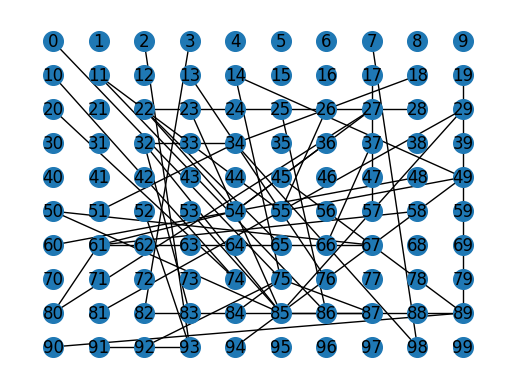

In [3]:
n = 10
G = nx.grid_2d_graph(n,n)

pos = dict( (n,n) for n in G.nodes() )

labels = dict( ((i, j), i + (n - 1 - j) * n) for i, j in G.nodes())

nx.relabel_nodes(G, labels, copy=False)

pos = {y:x for x,y in labels.items()}

G2 = nx.erdos_renyi_graph(100, 0.01)
nx.draw_networkx(G2, pos=pos, with_labels=True, node_size=200)
print(G.nodes())
plt.axis('off')
plt.show()


In [4]:

# Matrice de dette A, B, C, D
P = np.array([
    [0, 180, 0, 0],
    [0, 0, 100, 0],
    [100, 0, 0, 100],
    [150, 0, 0, 0]
])

# vecteur de pret
c = np.array([120, 30, 160, 204])

# vecteur de dette
b = np.array([180, 100, 50, 150])

# Net worth de chaque banque A, B, C, D
w = np.array([10, 10, 10, 4])

# Poids des dettes d'une banque à une autre
A = np.array([
    [0, 1/2, 0, 0],
    [0, 0, 1/2, 0],
    [2/5, 0, 0, 2/5],
    [1/2, 0, 0, 0]
])

# Vecteur de shock de test
x_shock = np.array([0, 0, 120, 0])

def payments0(P: np.array, A: np.array, b: np.array, c: np.array, x_shock: np.array) -> np.array:
    """ Le vecteur de payement p"""
    p = np.zeros(len(b))
    p_total_liabilities = [sum(P[i]) + b[i] for i in range(len(c))]
    sum1 = A.T@p
    p = np.minimum(p_total_liabilities, np.maximum(0,c - x_shock+ sum1))
    return p



def iteration_payements(c, P, b, x_shock, A, p0, tol=1e-10):
    p_total_liabilities = np.sum(P, 1) + b
    while True:
        p_old = p0.copy()
        p0 = np.minimum(p_total_liabilities, np.maximum(0, c - x_shock + A.T@p0))
        if np.allclose(p0, p_old, rtol=tol):
            return p0



array([1, 1, 1, ..., 1, 1, 1], shape=(50000,))

In [5]:
class Simulation:
    """
    Je compte simuler la robustesse d'un reseau interbancaire.

    Mais d'abord, on va simplement simuler selon la topologie d'un réseau interbancaire, l'impact d'un shock.

    Ainsi, on va avant tous
    """


    def __init__(self,
                 assets_vector: np.array,
                 liabilities_vector: np.array,
                 net_worth: np.array,
                 weight_of_obligation_matrix: np.array):

        self.obligation_matrix = np.zeros((len(assets_vector), len(assets_vector))) # Pour une simulation de la robustesse d'un reseau je peux choisir les obligations en fonction d'une variable aléatoire simple,
        self.vector_prix_depart = np.zeros((len(assets_vector)))
        self.assets_vector = assets_vector
        self.liabilities_vector = liabilities_vector
        self.net_worth = net_worth
        self.weight_of_obligation_matrix = weight_of_obligation_matrix
        #self.relative_vulnerability_matrix = np.zeros((len(assets_vector), len(assets_vector)))
        #self.vulnerabilities_vector = np.zeros(len(assets_vector))



    def compute_relative_vulnerabilities(self) -> None:
        """
        Pas encore sur de garder cette fonction sous cette forme, mais a chaque fois qu'on change une valeur de la matrice d'obligation, on doit adapter les vulnerabilités.
        :return:
        """
        for i in range(len(self.assets_vector)):
            for j in range(len(self.assets_vector)):
                self.relative_vulnerability_matrix[i][j] = self.weight_of_obligation_matrix[j][i]*(
                    self.assets_vector[j] - self.net_worth[j]
                )/self.net_worth[j]
        return


    def compute_vulnerabilities_vectors(self) -> None:
        for i in range(len(self.assets_vector)):
            temp = [self.obligation_matrix[k][i] for k in range(len(self.assets_vector))]
            self.vulnerabilities_vector[i] = max(temp)
        return

    def random_obligation_matrix(self, probability_forming_a_link) -> None:
        """
        Nous donne un reseau fixe au depart,
        :return:
        """
        for k in range(len(self.assets_vector)):
            for j in range(len(self.assets_vector)):
                if np.random.random() < probability_forming_a_link:
                    obligation_amount = np.random.lognormal()
                    self.obligation_matrix[k][j] = obligation_amount
        return


    def update(self, chock_x: np.array) -> None:
        """
        Ce chock est appliqué aux nœuds du reseau interbancaire,  plus specifiquement aux actifs exterieur a chaque banque.
        :param chock_x:
        :return:
        """
        vector_of_default = np.zeros(len(chock_x))
        for i in range(len(self.assets_vector)):
            self.net_worth[i] -= chock_x[i]
            if self.net_worth[i] <= 0:
                vector_of_default[i] = 1





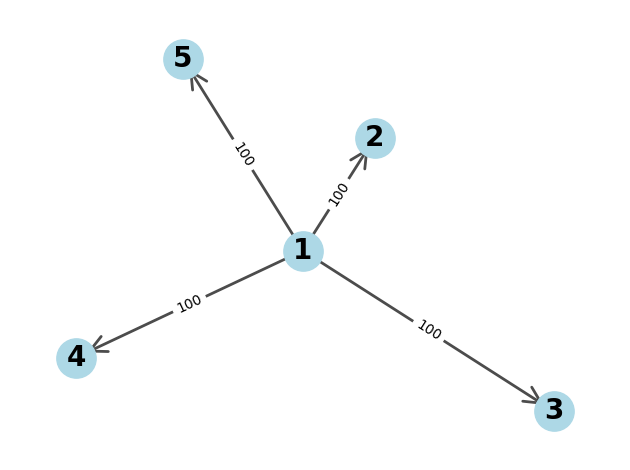

In [6]:
G = nx.DiGraph()

G.add_weighted_edges_from([
    (1, 2, 100),
    (1, 3, 100),
    (1, 4, 100),
    (1, 5, 100)
])



pos = nx.spring_layout(G, k=2, iterations=50)

nx.draw_networkx_nodes(G, pos=pos, node_size=800, node_color='lightblue')
nx.draw_networkx_edges(G, pos=pos, width=2, alpha=0.7, arrowstyle='->', arrowsize=30)

nx.draw_networkx_labels(G, pos=pos, font_size=20, font_weight='bold', font_family='sans-serif')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels)


ax = plt.gca()
ax.axis('off')
ax.margins(0.08)
plt.tight_layout()
plt.show()


In [7]:
# Implémentation du modèle Eisenberg-Noe pour la contagion financière
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def eisenberg_noe_clearing(L, e, max_iterations=100, tol=1e-6):
    """
    Calcule le vecteur de paiement d'équilibre selon le modèle Eisenberg-Noe

    Paramètres:
    L (numpy.ndarray): Matrice des engagements interbancaires
    e (numpy.ndarray): Vecteur des actifs externes
    max_iterations: Nombre maximal d'itérations
    tol: Tolérance pour la convergence

    Retourne:
    numpy.ndarray: Vecteur de paiement d'équilibre
    """
    n = len(e)
    p_bar = np.sum(L, axis=1)  # Vecteur des engagements totaux

    # Matrice des proportions
    Pi = np.zeros((n, n))
    for i in range(n):
        if p_bar[i] > 0:
            Pi[i, :] = L[i, :] / p_bar[i]

    # Algorithme de point fixe
    p = p_bar.copy()
    for _ in range(max_iterations):
        p_new = np.minimum(p_bar, e + Pi.T @ p)
        if np.linalg.norm(p_new - p) < tol:
            return p_new
        p = p_new

    return p

def calculate_vulnerability_index(G, L, e, shocks):
    """
    Calcule l'indice de vulnérabilité pour chaque nœud du réseau

    Paramètres:
    G (networkx.DiGraph): Graphe dirigé représentant le réseau interbancaire
    L (numpy.ndarray): Matrice des engagements interbancaires
    e (numpy.ndarray): Vecteur des actifs externes initial
    shocks (list): Liste des chocs à simuler

    Retourne:
    dict: Indice de vulnérabilité pour chaque nœud
    """
    n = len(G.nodes())
    vulnerability = {node: 0 for node in G.nodes()}

    # Pour chaque scénario de choc
    for shock in shocks:
        e_shocked = e.copy()
        e_shocked[shock['node']] *= (1 - shock['magnitude'])

        # Calcul du vecteur de paiement d'équilibre
        p = eisenberg_noe_clearing(L, e_shocked)

        # Calcul des défauts
        defaults = p < np.sum(L, axis=1) - 1e-6

        # Mise à jour de l'indice de vulnérabilité
        for i, node in enumerate(G.nodes()):
            if defaults[i]:
                vulnerability[node] += 1

    # Normalisation
    num_shocks = len(shocks)
    for node in vulnerability:
        vulnerability[node] /= num_shocks

    return vulnerability

# Exemple d'utilisation
def simulate_network_contagion():
    # Création d'un réseau aléatoire
    n = 10  # Nombre de banques
    p = 0.2  # Probabilité de connexion

    G = nx.gnp_random_graph(n, p, directed=True)

    # Génération des bilans aléatoires
    np.random.seed(42)
    external_assets = np.random.uniform(50, 150, n)

    # Matrice des engagements interbancaires
    L = np.zeros((n, n))
    for i, j in G.edges():
        L[i, j] = np.random.uniform(5, 20)

    # Vecteur des actifs externes
    e = external_assets.copy()

    # Définition des scénarios de choc
    shocks = [
        {'node': i, 'magnitude': 0.5} for i in range(n)
    ]

    # Calcul de l'indice de vulnérabilité
    vulnerability = calculate_vulnerability_index(G, L, e, shocks)

    # Visualisation du réseau avec indice de vulnérabilité
    pos = nx.spring_layout(G)
    node_colors = [vulnerability[node] for node in G.nodes()]

    plt.figure(figsize=(10, 8))
    nx.draw_networkx(G, pos, node_color=node_colors,
                    node_size=800, cmap=plt.cm.Reds,
                    with_labels=True)

    edge_labels = {(i, j): f"{L[i, j]:.1f}" for i, j in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Réseau interbancaire avec indice de vulnérabilité")
    plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Reds),
                label="Indice de vulnérabilité")
    plt.axis('off')
    plt.tight_layout()

    return G, L, e, vulnerability

In [8]:
P @ np.array([1]*4)


array([180, 100, 200, 150])

In [9]:
min(int(np.random.lognormal(2, 1)*500), 500)

500

In [525]:
# 1. D'abord, importez tous les modules concernés
import model
import model.bank
import model.network
from model.network import NetworkGenerator
from model.bank import Bank
from importlib import reload

# 2. Rechargez dans le bon ordre (du plus spécifique au plus général)
reload(model.bank)
reload(model.network)
reload(model)

# 3. Réimportez la classe après le rechargement
from model.bank import Bank
from model.network import NetworkGenerator

In [526]:


bank = Bank(0,0,0,1)

In [560]:
network_banks = NetworkGenerator(5, True, 0.5)
network_banks.net_worth


array([  6,   3,  18, 305, 211])

In [471]:
np.random.uniform(1, 5)


1.4169534560484611

In [493]:
abs(-10)

10

In [15]:
from itertools import count

a = [2, -1, 9, -2]
b = [a[i]<0 for i in range(len(a))]
cunt = b.count(True)


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
int((10+6)/10)

1

In [83]:
def check_valide(s:str):
    pass

def lengthOfLongestSubstring( s: str) -> int:

        max_sub = 0
        deja_vue = []
        k, j = 0, 1
        while k < len(s) and j < len(s):
            if s[k] == s[j]:
                if max_sub <= 1:
                    max_sub = 1
                deja_vue.append(s[k])
                deja_vue.append(s[j])
            elif deja_vue.count(s[k]) == 0 and deja_vue.count(s[j]) == 0:
                max_sub += 2
                print(max_sub, deja_vue)
                deja_vue.append(s[k])
                deja_vue.append(s[j])
            elif deja_vue.count(s[k]) != 0 and deja_vue.count(s[j]) == 0:
                print("On est dans 1")
                max_sub += 1
                deja_vue.append(s[j])
            elif deja_vue.count(s[k]) != 0 and deja_vue.count(s[j]) == 0:
                print("On est dans 2")
                max_sub += 1
                deja_vue.append(s[k])


            k = j + 1
            j = j + 2


        return max_sub

In [94]:
lengthOfLongestSubstring("abcdecbb")

2 []
4 ['a', 'b']


4

In [101]:
string = "aaaabssdiezd"


1